In [1]:
import os
import re
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

import albumentations as A
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
CFG = {
    "data_root": r"C:\Users\ASHAH\Desktop\DL_Project\breast_ultrasound\combined_breast_ultrasound_dataset",
    "img_size": 320,
    "batch_size": 8,
    "epochs": 50,
    "lr": 3e-4,
    "num_workers": 0,
    "encoder_name": "timm-efficientnet-b3",   # fallback: "efficientnet-b3"
    "threshold": 0.5,
    "num_classes": 3,          # benign, malignant, normal
    "cls_weight": 0.4,         # weight for classification loss in combined loss
}

# Label mapping
LABEL2IDX = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}


In [3]:
DATASET_ROOT = Path(CFG["data_root"])

def base_key(filename: str) -> str:
    name = filename.replace(".png", "")
    name = re.sub(r"_mask(_\d+)?$", "", name)
    return name

rows = []
for cls_name in ["benign", "malignant", "normal"]:
    cls_dir  = DATASET_ROOT / cls_name
    img_dir  = cls_dir / "images"
    mask_dir = cls_dir / "masks"

    masks = {
        re.sub(r"_mask$", "", p.stem): str(p)
        for p in mask_dir.glob("*.png")
    }

    for img_path in sorted(img_dir.glob("*.png")):
        key = img_path.stem
        rows.append({
            "image_path": str(img_path),
            "mask_path":  masks.get(key, None),
            "label":      cls_name,
            "label_idx":  LABEL2IDX[cls_name],
        })

df = pd.DataFrame(rows)
print(df["label"].value_counts())
print("Total:", len(df))
print("With mask:", df["mask_path"].notna().sum())
print("Without mask:", df["mask_path"].isna().sum())


label
normal       729
benign       477
malignant    261
Name: count, dtype: int64
Total: 1467
With mask: 1467
Without mask: 0


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print(train_df["label"].value_counts(), "\n")
print("Valid:", len(valid_df))
print(valid_df["label"].value_counts(), "\n")
print("Test:", len(test_df))
print(test_df["label"].value_counts())


Train: 1026
label
normal       510
benign       334
malignant    182
Name: count, dtype: int64 

Valid: 220
label
normal       109
benign        71
malignant     40
Name: count, dtype: int64 

Test: 221
label
normal       110
benign        72
malignant     39
Name: count, dtype: int64


In [5]:
# ── Augmentation transforms (used in augmented experiment) ──────────────────
train_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),
])
valid_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])

# ── No-augmentation transforms (baseline) ───────────────────────────────────
train_tfms_noaug = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])
valid_tfms_noaug = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])


C:\Users\ASHAH\anaconda3\envs\ml_env\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:
class BUSISegDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(row["image_path"])

        mask_path = row["mask_path"]
        if mask_path and Path(mask_path).exists():
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros(image.shape, dtype=np.float32)

        h, w = CFG["img_size"], CFG["img_size"]
        image = cv2.resize(image, (w, h), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (w, h), interpolation=cv2.INTER_NEAREST)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask  = transformed["mask"]

        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        mask  = np.expand_dims(mask.astype(np.float32), axis=0)

        return {
            "image":     torch.tensor(image, dtype=torch.float32),
            "mask":      torch.tensor(mask,  dtype=torch.float32),
            "label":     row["label"],
            "label_idx": torch.tensor(row["label_idx"], dtype=torch.long),
        }


In [7]:
class DualTaskModel(nn.Module):
    """
    DeepLabV3+ backbone (segmentation) + lightweight classification head.
    The classification head attaches to the encoder's final feature map via
    global average pooling so it adds almost no extra parameters.
    """
    def __init__(self, encoder_name, num_classes=3):
        super().__init__()
        # ── Segmentation branch ──────────────────────────────────────────────
        self.seg_model = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=1,
            classes=1,
            activation=None,
        )

        # ── Classification head  ─────────────────────────────────────────────
        # Probe the encoder output channels dynamically
        dummy = torch.zeros(1, 1, CFG["img_size"], CFG["img_size"])
        with torch.no_grad():
            enc_out = self.seg_model.encoder(dummy)
        enc_channels = enc_out[-1].shape[1]   # last-stage feature channels

        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),           # → [B, C, 1, 1]
            nn.Flatten(),                       # → [B, C]
            nn.Linear(enc_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),        # → [B, num_classes]
        )

    def forward(self, x):
        # Run encoder once, share features for both tasks
        enc_features = self.seg_model.encoder(x)           # list of feature maps
        decoder_out  = self.seg_model.decoder(enc_features)
        seg_logits   = self.seg_model.segmentation_head(decoder_out)   # [B,1,H,W]
        cls_logits   = self.cls_head(enc_features[-1])                  # [B, num_classes]
        return seg_logits, cls_logits

    def freeze_encoder(self):
        for p in self.seg_model.encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.seg_model.encoder.parameters():
            p.requires_grad = True


# ── Quick shape test ─────────────────────────────────────────────────────────
_tmp = DualTaskModel(CFG["encoder_name"], CFG["num_classes"]).to(device)
_x   = torch.randn(2, 1, CFG["img_size"], CFG["img_size"]).to(device)
with torch.no_grad():
    _seg, _cls = _tmp(_x)
print("Seg logits shape:", _seg.shape)   # [2, 1, H, W]
print("Cls logits shape:", _cls.shape)   # [2, 3]
del _tmp, _x, _seg, _cls


Seg logits shape: torch.Size([2, 1, 320, 320])
Cls logits shape: torch.Size([2, 3])


In [8]:
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss  = nn.BCEWithLogitsLoss()
ce_loss   = nn.CrossEntropyLoss()

def compute_combined_loss(seg_logits, cls_logits, masks, labels):
    """
    Combined segmentation + classification loss.
    seg_loss  = Dice + BCE  (binary segmentation)
    cls_loss  = CrossEntropy (3-class)
    total     = seg_loss + cls_weight * cls_loss
    """
    seg_loss = dice_loss(seg_logits, masks) + bce_loss(seg_logits, masks)
    cls_loss = ce_loss(cls_logits, labels)
    return seg_loss + CFG["cls_weight"] * cls_loss, seg_loss, cls_loss


In [9]:
def dice_score_from_logits(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    dice  = (2 * inter + eps) / (union + eps)
    return dice.mean().item()

def cls_accuracy(cls_logits, labels):
    preds = cls_logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


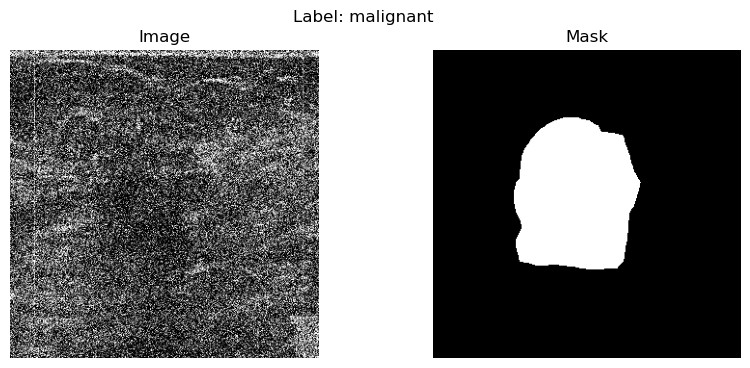

In [10]:
def make_loaders(train_tfms, val_tfms, tag="aug"):
    train_ds = BUSISegDataset(train_df, transforms=train_tfms)
    valid_ds = BUSISegDataset(valid_df, transforms=val_tfms)
    test_ds  = BUSISegDataset(test_df,  transforms=val_tfms)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True)
    valid_loader = DataLoader(valid_ds, batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=0, pin_memory=True)
    print(f"[{tag}] train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")
    return train_loader, valid_loader, test_loader, valid_ds, test_ds

# Sanity check: visualise one sample
_ds = BUSISegDataset(train_df, transforms=train_tfms)
sample = _ds[0]
img = sample["image"][0].numpy()
msk = sample["mask"][0].numpy()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(msk, cmap="gray"); plt.title("Mask");  plt.axis("off")
plt.suptitle(f"Label: {sample['label']}"); plt.show()


In [11]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    totals = dict(loss=0, seg_loss=0, cls_loss=0, dice=0, acc=0)

    pbar = tqdm(loader, total=len(loader))
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        masks  = batch["mask"].to(device, non_blocking=True)
        labels = batch["label_idx"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            seg_logits, cls_logits = model(images)
            loss, seg_l, cls_l = compute_combined_loss(seg_logits, cls_logits, masks, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score_from_logits(seg_logits.detach(), masks)
        totals["acc"]      += cls_accuracy(cls_logits.detach(), labels)

        n = pbar.n + 1
        pbar.set_postfix({k: f"{v/n:.4f}" for k, v in totals.items()})

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def valid_one_epoch(model, loader):
    model.eval()
    totals = dict(loss=0, seg_loss=0, cls_loss=0, dice=0, acc=0)

    for batch in tqdm(loader, total=len(loader)):
        images = batch["image"].to(device, non_blocking=True)
        masks  = batch["mask"].to(device, non_blocking=True)
        labels = batch["label_idx"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            seg_logits, cls_logits = model(images)
            loss, seg_l, cls_l = compute_combined_loss(seg_logits, cls_logits, masks, labels)

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score_from_logits(seg_logits, masks)
        totals["acc"]      += cls_accuracy(cls_logits, labels)

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


In [12]:
def run_experiment(tag, train_tfms, val_tfms, save_path):
    """
    Full training pipeline for one experiment (no-aug or aug).
    Returns: history dict, trained model, loaders
    """
    print("\n" + "="*60)
    print(f"  EXPERIMENT: {tag}")
    print("="*60)

    train_loader, valid_loader, test_loader, valid_ds, test_ds = \
        make_loaders(train_tfms, val_tfms, tag)

    model     = DualTaskModel(CFG["encoder_name"], CFG["num_classes"]).to(device)
    model.freeze_encoder()
    print("Encoder frozen ✓")

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=1e-2)
    scaler    = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"], eta_min=1e-6
    )

    history    = {k: [] for k in ["train_loss","train_dice","train_acc",
                                    "val_loss","val_dice","val_acc"]}
    best_dice  = -1
    patience   = 10
    no_improve = 0

    for epoch in range(CFG["epochs"]):
        if epoch == 5:
            model.unfreeze_encoder()
            print("Encoder unfrozen ✓")

        tr = train_one_epoch(model, train_loader, optimizer, scaler)
        vl = valid_one_epoch(model, valid_loader)
        scheduler.step()

        history["train_loss"].append(tr["loss"])
        history["train_dice"].append(tr["dice"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(vl["loss"])
        history["val_dice"].append(vl["dice"])
        history["val_acc"].append(vl["acc"])

        print(f"\nEpoch {epoch+1}/{CFG['epochs']}  [{tag}]")
        print(f"  Train  loss={tr['loss']:.4f}  dice={tr['dice']:.4f}  acc={tr['acc']:.4f}")
        print(f"  Val    loss={vl['loss']:.4f}  dice={vl['dice']:.4f}  acc={vl['acc']:.4f}")
        print(f"  LR: {scheduler.get_last_lr()[0]:.2e}")

        if vl["dice"] > best_dice:
            best_dice = vl["dice"]
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model → {save_path}")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    return history, model, train_loader, valid_loader, test_loader, valid_ds, test_ds


## Experiment 1 — Without Augmentation (Baseline)
Run the no-augmentation experiment first so it serves as the baseline for comparison.

In [13]:
history_noaug, model_noaug, \
    train_loader_noaug, valid_loader_noaug, test_loader_noaug, \
    valid_ds_noaug, test_ds_noaug = run_experiment(
        tag         = "NoAug",
        train_tfms  = train_tfms_noaug,
        val_tfms    = valid_tfms_noaug,
        save_path   = "best_noaug_model.pth",
)



  EXPERIMENT: NoAug
[NoAug] train=1026  valid=220  test=221
Encoder frozen ✓


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 1/50  [NoAug]
  Train  loss=1.3743  dice=0.3493  acc=0.6521
  Val    loss=1.1104  dice=0.4993  acc=0.6518
  LR: 3.00e-04
  ✓ Saved best model → best_noaug_model.pth


  0%|          | 0/129 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 35/50  [NoAug]
  Train  loss=0.0867  dice=0.9674  acc=0.9622
  Val    loss=0.7857  dice=0.8303  acc=0.8036
  LR: 6.26e-05


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 36/50  [NoAug]
  Train  loss=0.0858  dice=0.9677  acc=0.9651
  Val    loss=0.7753  dice=0.8306  acc=0.8214
  LR: 5.52e-05
  Early stopping at epoch 36


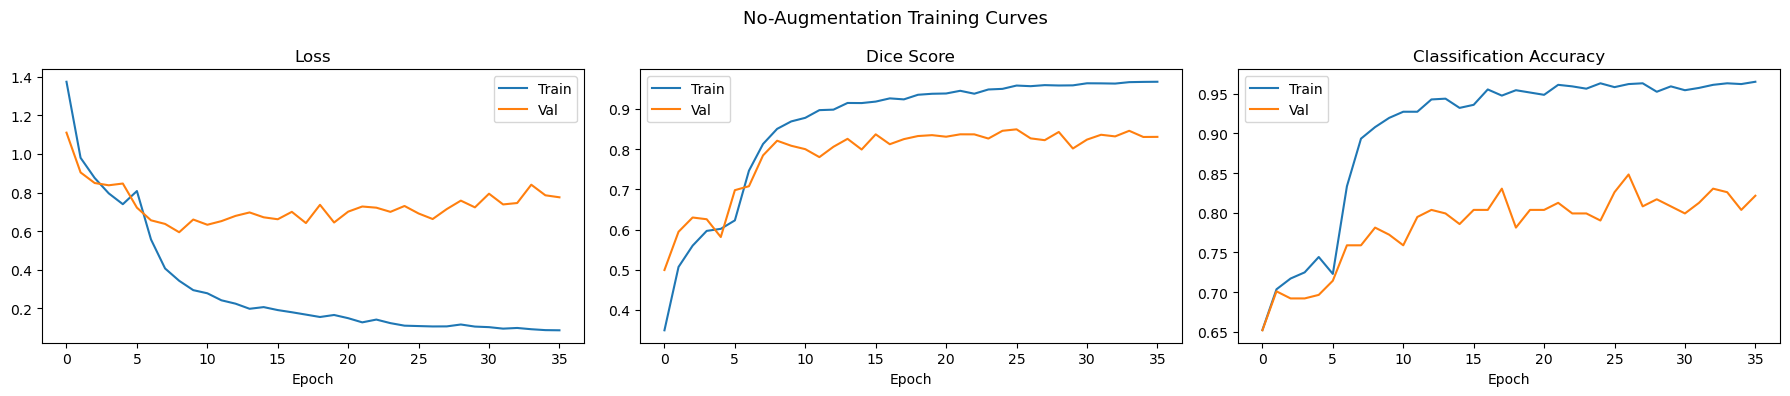

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("No-Augmentation Training Curves", fontsize=13)

axes[0].plot(history_noaug["train_loss"], label="Train")
axes[0].plot(history_noaug["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_noaug["train_dice"], label="Train")
axes[1].plot(history_noaug["val_dice"],   label="Val")
axes[1].set_title("Dice Score"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history_noaug["train_acc"], label="Train")
axes[2].plot(history_noaug["val_acc"],   label="Val")
axes[2].set_title("Classification Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("noaug_training_curves.png", dpi=150)
plt.show()


In [15]:
# ── Test evaluation: No-Aug ──────────────────────────────────────────────────
model_noaug.load_state_dict(torch.load("best_noaug_model.pth", map_location=device))
model_noaug.eval()

test_metrics_noaug = valid_one_epoch(model_noaug, test_loader_noaug)
print("\n[No-Aug] Test Results")
print(f"  Loss={test_metrics_noaug['loss']:.4f}  "
      f"Dice={test_metrics_noaug['dice']:.4f}  "
      f"Cls Acc={test_metrics_noaug['acc']:.4f}")


  0%|          | 0/28 [00:00<?, ?it/s]


[No-Aug] Test Results
  Loss=0.7127  Dice=0.8188  Cls Acc=0.8304



[No-Aug] Classification Report:
              precision    recall  f1-score   support

      benign       0.82      0.69      0.75        72
   malignant       0.80      0.82      0.81        39
      normal       0.84      0.92      0.88       110

    accuracy                           0.83       221
   macro avg       0.82      0.81      0.81       221
weighted avg       0.83      0.83      0.83       221



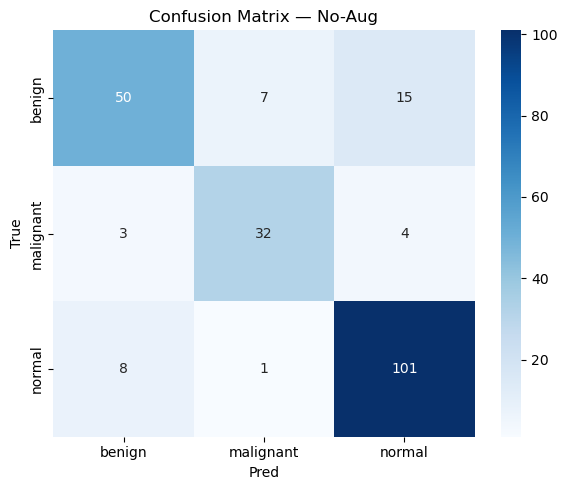

In [16]:
@torch.no_grad()
def collect_cls_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label_idx"]
        _, cls_logits = model(images)
        preds = cls_logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
    return all_labels, all_preds

labels_noaug, preds_noaug = collect_cls_preds(model_noaug, test_loader_noaug)

print("\n[No-Aug] Classification Report:")
print(classification_report(labels_noaug, preds_noaug,
                             target_names=["benign","malignant","normal"]))

cm = confusion_matrix(labels_noaug, preds_noaug)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["benign","malignant","normal"],
            yticklabels=["benign","malignant","normal"])
plt.title("Confusion Matrix — No-Aug"); plt.ylabel("True"); plt.xlabel("Pred")
plt.tight_layout(); plt.savefig("cm_noaug.png", dpi=150); plt.show()


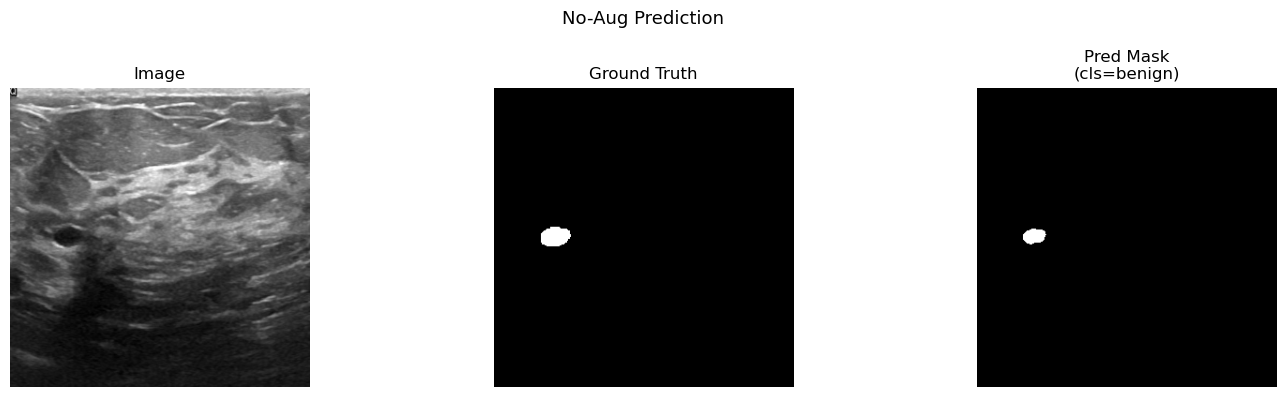

In [17]:
# ── Visual segmentation prediction — No-Aug ──────────────────────────────────
sample = test_ds_noaug[0]
img_t  = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    seg_logits, cls_logits = model_noaug(img_t)
    pred_mask = (torch.sigmoid(seg_logits)[0, 0] > CFG["threshold"]).float().cpu().numpy()
    pred_cls  = IDX2LABEL[cls_logits.argmax(dim=1).item()]

img    = sample["image"][0].numpy()
gt_msk = sample["mask"][0].numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(gt_msk, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(pred_mask, cmap="gray")
plt.title(f"Pred Mask\n(cls={pred_cls})"); plt.axis("off")
plt.suptitle("No-Aug Prediction", fontsize=13)
plt.tight_layout(); plt.savefig("noaug_prediction.png", dpi=150); plt.show()


## Experiment 2 — With Augmentation
Training with the full medical-imaging augmentation pipeline.

In [18]:
history_aug, model_aug, \
    train_loader_aug, valid_loader_aug, test_loader_aug, \
    valid_ds_aug, test_ds_aug = run_experiment(
        tag        = "Aug",
        train_tfms = train_tfms,
        val_tfms   = valid_tfms,
        save_path  = "best_aug_model.pth",
)



  EXPERIMENT: Aug
[Aug] train=1026  valid=220  test=221
Encoder frozen ✓


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 1/50  [Aug]
  Train  loss=1.4707  dice=0.2934  acc=0.5766
  Val    loss=1.1644  dice=0.3868  acc=0.6384
  LR: 3.00e-04
  ✓ Saved best model → best_aug_model.pth


  0%|          | 0/129 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 29/50  [Aug]
  Train  loss=0.3248  dice=0.8602  acc=0.9176
  Val    loss=0.5420  dice=0.8244  acc=0.8080
  LR: 1.13e-04


  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]


Epoch 30/50  [Aug]
  Train  loss=0.3127  dice=0.8772  acc=0.9147
  Val    loss=0.4764  dice=0.8455  acc=0.8348
  LR: 1.04e-04
  Early stopping at epoch 30


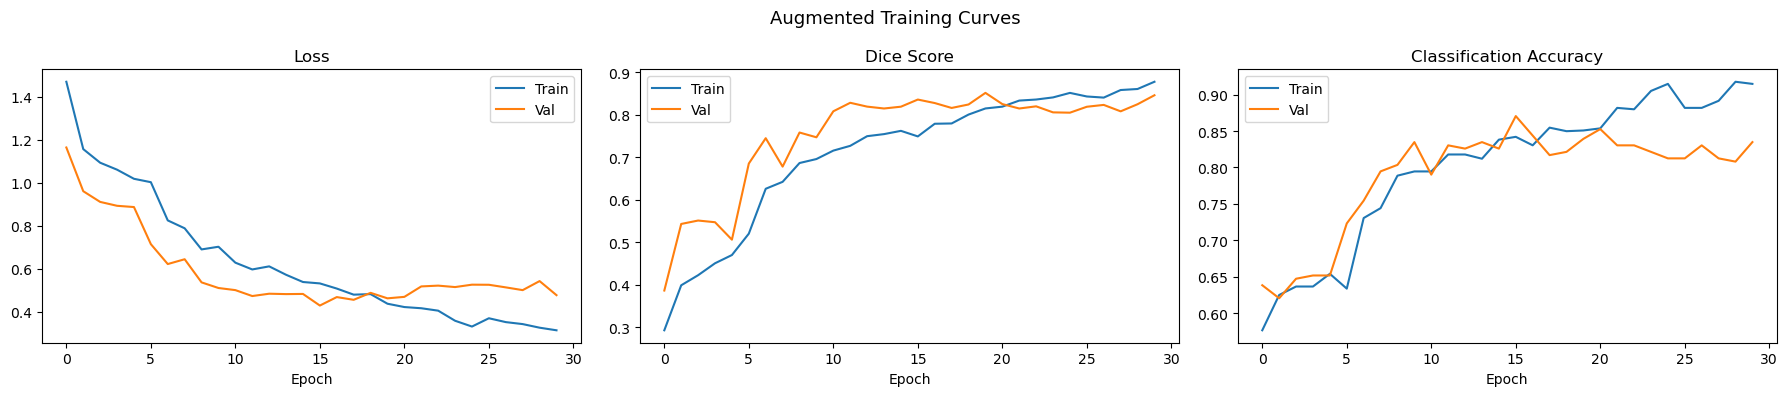

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Augmented Training Curves", fontsize=13)

axes[0].plot(history_aug["train_loss"], label="Train")
axes[0].plot(history_aug["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_aug["train_dice"], label="Train")
axes[1].plot(history_aug["val_dice"],   label="Val")
axes[1].set_title("Dice Score"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history_aug["train_acc"], label="Train")
axes[2].plot(history_aug["val_acc"],   label="Val")
axes[2].set_title("Classification Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("aug_training_curves.png", dpi=150)
plt.show()


In [20]:
# ── Test evaluation: Aug ─────────────────────────────────────────────────────
model_aug.load_state_dict(torch.load("best_aug_model.pth", map_location=device))
model_aug.eval()

test_metrics_aug = valid_one_epoch(model_aug, test_loader_aug)
print("\n[Aug] Test Results")
print(f"  Loss={test_metrics_aug['loss']:.4f}  "
      f"Dice={test_metrics_aug['dice']:.4f}  "
      f"Cls Acc={test_metrics_aug['acc']:.4f}")


  0%|          | 0/28 [00:00<?, ?it/s]


[Aug] Test Results
  Loss=0.5130  Dice=0.8161  Cls Acc=0.8143



[Aug] Classification Report:
              precision    recall  f1-score   support

      benign       0.78      0.72      0.75        72
   malignant       0.77      0.77      0.77        39
      normal       0.85      0.89      0.87       110

    accuracy                           0.81       221
   macro avg       0.80      0.79      0.80       221
weighted avg       0.81      0.81      0.81       221



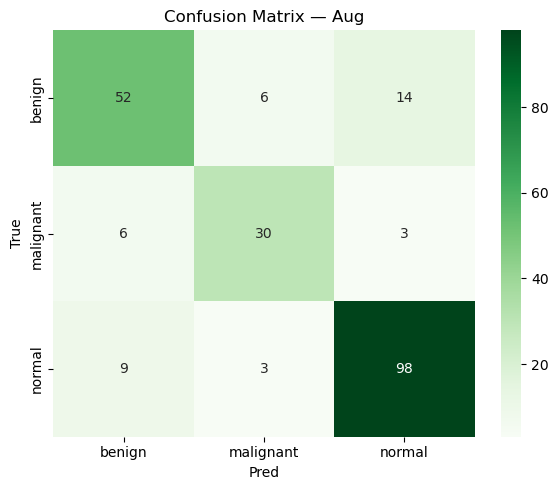

In [21]:
labels_aug, preds_aug = collect_cls_preds(model_aug, test_loader_aug)

print("\n[Aug] Classification Report:")
print(classification_report(labels_aug, preds_aug,
                             target_names=["benign","malignant","normal"]))

cm = confusion_matrix(labels_aug, preds_aug)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["benign","malignant","normal"],
            yticklabels=["benign","malignant","normal"])
plt.title("Confusion Matrix — Aug"); plt.ylabel("True"); plt.xlabel("Pred")
plt.tight_layout(); plt.savefig("cm_aug.png", dpi=150); plt.show()


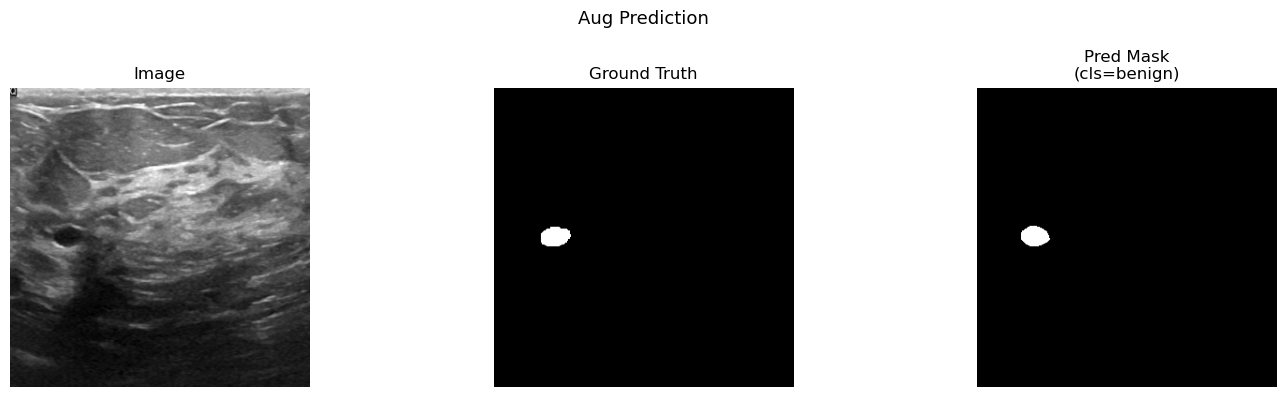

In [22]:
# ── Visual segmentation prediction — Aug ─────────────────────────────────────
sample = test_ds_aug[0]
img_t  = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    seg_logits, cls_logits = model_aug(img_t)
    pred_mask = (torch.sigmoid(seg_logits)[0, 0] > CFG["threshold"]).float().cpu().numpy()
    pred_cls  = IDX2LABEL[cls_logits.argmax(dim=1).item()]

img    = sample["image"][0].numpy()
gt_msk = sample["mask"][0].numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(gt_msk, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(pred_mask, cmap="gray")
plt.title(f"Pred Mask\n(cls={pred_cls})"); plt.axis("off")
plt.suptitle("Aug Prediction", fontsize=13)
plt.tight_layout(); plt.savefig("aug_prediction.png", dpi=150); plt.show()


## Final Comparison: No-Aug vs. Aug

In [23]:
# ── Side-by-side metric comparison ───────────────────────────────────────────
print("=" * 52)
print(f"{'Metric':<22}{'No-Aug':>12}{'Aug':>12}{'Gain':>8}")
print("-" * 52)
for key, label in [("dice","Test Dice"), ("acc","Test Cls Acc"), ("loss","Test Loss")]:
    na = test_metrics_noaug[key]
    au = test_metrics_aug[key]
    diff = au - na
    sign = "+" if diff >= 0 else ""
    print(f"  {label:<20}{na:>12.4f}{au:>12.4f}{sign+f'{diff:.4f}':>8}")
print("=" * 52)


Metric                      No-Aug         Aug    Gain
----------------------------------------------------
  Test Dice                 0.8188      0.8161 -0.0027
  Test Cls Acc              0.8304      0.8143 -0.0161
  Test Loss                 0.7127      0.5130 -0.1997


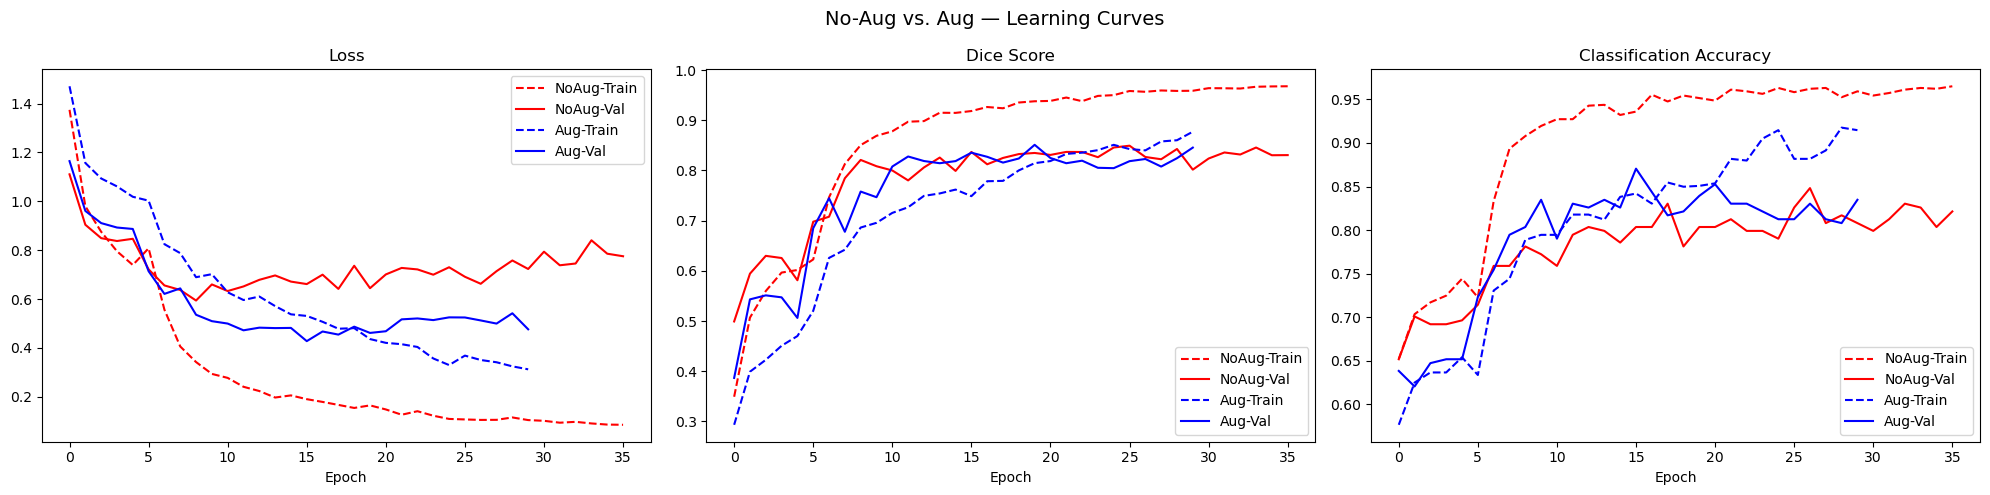

In [24]:
# ── Side-by-side learning curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("No-Aug vs. Aug — Learning Curves", fontsize=14)

keys = [("loss","Loss"),("dice","Dice Score"),("acc","Classification Accuracy")]
for ax, (key, title) in zip(axes, keys):
    ax.plot(history_noaug[f"train_{key}"], "--", color="red",   label="NoAug-Train")
    ax.plot(history_noaug[f"val_{key}"],   "-",  color="red",   label="NoAug-Val")
    ax.plot(history_aug[f"train_{key}"],   "--", color="blue",  label="Aug-Train")
    ax.plot(history_aug[f"val_{key}"],     "-",  color="blue",  label="Aug-Val")
    ax.set_title(title); ax.legend(); ax.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("aug_vs_noaug_comparison.png", dpi=150)
plt.show()
